In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_data.csv')

In [13]:
# show the first 5 rows
df.head()


,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0


In [14]:
# show the last 5 rows
df.tail()

,Starting (USD),Ending (USD)
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0
10,16800,16500.0
11,16700,NaN


In [15]:
# Random Rows
df.sample(5)

,Starting (USD),Ending (USD)
2,15900,16100.0
1,15800,15500.0
11,16700,NaN
4,16100,16200.0
0,15800,15300.0


In [16]:
# Shape
df.shape

(12, 2)

In [17]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Starting (USD)  12 non-null     int64  
 1   Ending (USD)    11 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 324.0 bytes


In [18]:
# Summary Statistics
df.describe()

,Starting (USD),Ending (USD)
count,12.000000,11.000000
mean,16229.166667,16000.000000
std,368.324421,376.828874
min,15800.000000,15300.000000
25%,15900.000000,15750.000000
50%,16175.000000,16100.000000
75%,16400.000000,16200.000000
max,16800.000000,16500.000000


In [19]:
# Summary Statistics for all columns
df.describe(include="all")

,Starting (USD),Ending (USD)
count,12.000000,11.000000
mean,16229.166667,16000.000000
std,368.324421,376.828874
min,15800.000000,15300.000000
25%,15900.000000,15750.000000
50%,16175.000000,16100.000000
75%,16400.000000,16200.000000
max,16800.000000,16500.000000


In [20]:
# Drop Unnecessary Columns
df.drop("Date", axis=1, inplace=True, errors="ignore")
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [21]:
# Count Missing Values
df.isnull().sum()

Starting (USD)    0
Ending (USD)      1
dtype: int64

In [22]:
df.duplicated()
df.drop_duplicates(inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


C:\Users\Omar Faruk\AppData\Local\Temp\ipykernel_4544\3078658429.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


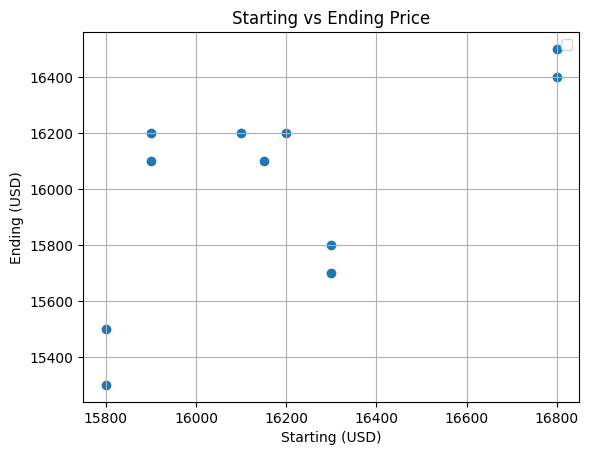

In [23]:
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.title('Starting vs Ending Price')
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Outliers Detection
Q1 = df["Starting (USD)"].quantile(0.25)
Q3 = df["Starting (USD)"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Starting (USD)"] < lower) |
    (df["Starting (USD)"] > upper)
]
print(outliers)

Empty DataFrame
Columns: [Starting (USD), Ending (USD)]
Index: []


In [25]:
# Multiple Numeric Columns Outliers
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[
    (df[col] >= lower) &
    (df[col] <= upper)
    ]
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [26]:
df.sort_values(["Starting (USD)", "Ending (USD)"], inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [47]:

# y = mx + c
m = model.coef_
c = model.intercept_
y = m * 16700 + c
y


array([16284.86956522])

In [56]:
# Predict all rows
